# **Import 단계**

- **기본 데이터 처리**

    - CSV 로드

    - 결측치 비율 확인

    - 데이터 타입 확인
    
- **데이터 분리 (훈련 / 검증)**

    - 학습용 / 검증용으로 분리해서 나타냄

- **전처리 핵심 도구**

    - 결측치 처리

    - 스케일링

    - 범주형 인코딩

- **시각화 (EDA용, 최소)**

    - target 분포 확인용

- **모델링 & 검증**

- **모델**



In [107]:
# catboost 설치
!pip install catboost

# 한글 깨짐 방지
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [108]:
# 기본 데이터 처리
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

# 데이터 분리 (훈련 / 검증)
from sklearn.model_selection import train_test_split

# 전처리용
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# 시각화 (EDA용, 최소)
import matplotlib.pyplot as plt
import seaborn as sns

# 모델링 & 검증(평가 지표)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score


# 모델 - Logistic Regression
from sklearn.linear_model import LogisticRegression
# 모델 - Random Forest
from sklearn.ensemble import RandomForestClassifier
# 모델 - Catboost
from catboost import Pool, CatBoostClassifier

# **Data Load & Check Data**

- **데이터 업로드**

    - test.csv

    - train.csv

    - sample_submission.csv
    
- **데이터 확인 (훈련)**

    - 데이터 크기

    - 컬럼 이름 전체 확인

    - 타겟 분포 : 'completed'

    - 결측치 존재 여부

    - 데이터 타입

- **Target / Feature 분리**

    - 분리 코드

    - X, y shape 확인

    - 타겟이 X에 섞여 있지 않은지 , y값 데이터 확인

    - 'ID'컬럼 제거 -> 과적합 방지

- **Train / Validation Split**

    - Stratified Split -> 비율을 유지한 채 분할

In [109]:
# 데이터 로드
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')

train.head()

,ID,generation,school1,major type,major1_1,major1_2,major_data,job,class1,class2,class3,class4,re_registration,contest_award,nationality,inflow_route,whyBDA,what_to_gain,hope_for_group,previous_class_3,previous_class_4,previous_class_5,previous_class_6,previous_class_7,previous_class_8,major_field,desired_career_path,completed_semester,project_type,time_input,desired_job,certificate_acquisition,desired_certificate,desired_job_except_data,incumbents_level,incumbents_lecture,incumbents_company_level,incumbents_lecture_type,incumbents_lecture_scale,incumbents_lecture_scale_reason,interested_company,expected_domain,contest_participation,idea_contest,onedayclass_topic,completed
0,TRAIN_000,9,22,"복수 전공 ( 다중전공, 이중전공 포함 )",경제통상학,자연과학,False,대학생,1,4.0,NaN,NaN,아니요,NaN,내국인,에브리타임,"큰 규모인 만큼, 커리큘럼이나 운영 등 관리가 잘 될것 같아서",프로젝트 경험,네. 온라인으로 참여하고 싶어요,NaN,NaN,NaN,NaN,NaN,NaN,"자연과학, 사회과학",대학원 진학,4.0,팀,2.0,C. 데이터 사이언티스트,컴퓨터활용능력,"ADsP, SQLD, 빅데이터 분석 기사, 태블로 관련 자격증, 구글 애널리스트",A. 금융 / 보험 직무,시니어 (10년차 ~),산업 트렌드 (예시: ChatGPT로 인한 직무 변화),해외 기업 (빅테크),"온, 오프라인 동시",100명 이상의 리스너와 10명 이상의 현직자,다양한 사람들과 만나서 생각을 교류할 수 있기 때문,"구글 딥마인드, 카카오 브레인","M. 전문, 과학 및 기술 서비스업",NaN,NaN,"Python 응용, 데이터 시각화 (Matplotlib, Seaborn 등), 머신...",0
1,TRAIN_001,9,1,"복수 전공 ( 다중전공, 이중전공 포함 )",자연과학,IT(컴퓨터 공학 포함),True,대학생,8,NaN,NaN,NaN,아니요,NaN,내국인,지인 추천,"큰 규모인 만큼, 커리큘럼이나 운영 등 관리가 잘 될것 같아서",데이터 분석 역량,네. 오프라인으로 참여하고 싶어요,NaN,NaN,NaN,NaN,NaN,NaN,사회과학,취업,6.0,팀,3.0,"B. 데이터 분석가, C. 데이터 사이언티스트",없음,"ADsP, SQLD, 빅데이터 분석 기사, 정보처리기사","D. 소프트웨어 개발자, F. PM / 서비스 기획자",주니어 (0~3년차),커리어 패스 과정 (예시: 비전공자/전공자의 취업 준비 및 이직 과정),국내 빅테크 IT 계열 (네카라쿠배당토),오프라인,3~50명 내외의 강의 리스너와 1명의 현직자,더 많은 사람들이 있으면 제가 예상하지 못한 질문도 할 수 있다고 생각하기 때문입니다.,제일 기획,"J. 정보통신업, O. 공공 행정, 국방 및 사회보장 행정",NaN,NaN,머신러닝 / 딥러닝 응용,0
2,TRAIN_002,9,27,단일 전공,예체능,NaN,False,대학생,7,NaN,NaN,NaN,아니요,NaN,내국인,인스타그램,"BDA 학회원만의 혜택을 누리고 싶어서(현직자 강연, 잡 페스티벌, 기업연계 공모전 등)",공모전 경험,네. 오프라인으로 참여하고 싶어요,NaN,NaN,NaN,NaN,NaN,NaN,예체능,대학원 진학,8.0,개인,10.0,"B. 데이터 분석가, C. 데이터 사이언티스트, I. 마케터",ADsP,"SQLD, 빅데이터 분석 기사, 정보처리기사","A. 금융 / 보험 직무, B. 기획 / 전략 / 경영 직무, H. 마케터 / 영업관리",주니어 (0~3년차),직무 강의 (예시: 실무 진행 방식 및 직무 준비생을 위한 팁),"국내 대기업 IT 계열 (금융, 제조 ...)",오프라인,3~50명 내외의 강의 리스너와 1명의 현직자,인원이 너무 적으면 서로 부담스러울 수 있을 것 같지만 너무 많으면 너무 피상적인 ...,Lg전자,"C. 제조업, K. 금융 및 보험업, R. 예술, 스포츠 및 여가관련 서비스업",NaN,NaN,"머신러닝 / 딥러닝 응용, SQL 응용, 웹 크롤링",0
3,TRAIN_003,9,1,"복수 전공 ( 다중전공, 이중전공 포함 )",사회과학,IT(컴퓨터 공학 포함),False,대학생,7,NaN,NaN,NaN,아니요,NaN,내국인,에브리타임,혼자 공부하기 어려워서,프로젝트 경험,네. 온라인으로 참여하고 싶어요,NaN,NaN,NaN,NaN,NaN,NaN,법학,취업,8.0,팀,2.0,"B. 데이터 분석가, C. 데이터 사이언티스트","SQLD, 정보처리기사","ADsP, 빅데이터 분석 기사",A. 금융 / 보험 직무,주니어 (0~3년차),커리어 패스 과정 (예시: 비전공자/전공자의 취업 준비 및 이직 과정),국내 빅테크 IT 계열 (네카라쿠배당토),"온, 오프라인 동시",3~50명 내외의 강의 리스너와 1명의 현직자,너무 많은 인원이 강의하면 루즈해질 것 같아서,네이버,"J. 정보통신업, K. 금융 및 보험업",NaN,NaN,머신러닝 / 딥러닝 응용,1
4,TRAIN_004,9,16,"복수 전공 ( 다중전공, 이중전공 포함 )",IT(컴퓨터 공학 포함),IT(컴퓨터 공학 포함),True,대학생,8,NaN,NaN,NaN,아니요,NaN,내국인,지인 추천,"큰 규모인 만큼, 커리큘럼이나 운영 등 관리가 잘 될것 같아서",공모전 경험,네. 오프라인으로 참여하고 싶어요,NaN,NaN,NaN,NaN,NaN,NaN,"IT (컴퓨터 공학 포함), 인문학",취업,7.0,팀,2.0,B. 데이터 분석가,ADsP,"SQLD, 정보처리기사, 태블로 관련 자격증, 구글 애널리스트","A. 금융 / 보험 직무, B. 기획 / 전략 / 경영 직무, F. PM / 서비스...",주니어 (0~3년차),직무 강의 (예시: 실무 진행 방식 및 직무 준비생을 위한 팁),"국내 대기업 IT 계열 (금융, 제조 ...)","온, 오프라인 동시",3~50명 내외의 강의 리스너와 1명의 현직자,다양한 사람들에게 기회가 있으면 좋겠습니다.,네이버,"K. 금융 및 보험업, M. 전문, 과학 및 기술 서비스업, R. 예술, 스포츠 및...",NaN,NaN,"머신러닝 / 딥러닝 응용, SQL 응용, 웹 크롤링",0


In [110]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               748 non-null    object 
 1   generation                       748 non-null    int64  
 2   school1                          748 non-null    int64  
 3   major type                       726 non-null    object 
 4   major1_1                         728 non-null    object 
 5   major1_2                         309 non-null    object 
 6   major_data                       748 non-null    bool   
 7   job                              748 non-null    object 
 8   class1                           748 non-null    int64  
 9   class2                           169 non-null    float64
 10  class3                           14 non-null     float64
 11  class4                           1 non-null      float64
 12  re_registration       

In [111]:
# --- 여기에 셀을 새로 하나 추가해서 파생 변수를 만드세요 ---

# 1. 텍스트 길이 (의지력 측정)
for df in [train, test]:
    df['why_len'] = df['whyBDA'].astype(str).apply(len)
    df['gain_len'] = df['what_to_gain'].astype(str).apply(len)

# 2. 리스트 형태 데이터 개수 세기 (관심도 측정)
def count_items(x):
    if pd.isna(x) or x == '없음' or x == 'nan': return 0
    return len(str(x).split(','))

list_cols = ['desired_certificate', 'expected_domain', 'onedayclass_topic']
for df in [train, test]:
    for col in list_cols:
        df[f'{col}_count'] = df[col].apply(count_items)

In [112]:
# 훈련용, 검증용 데이터 크기 확인
train.shape, test.shape

((748, 51), (814, 50))

In [113]:
# 훈련용 데이터 컬럼확인
train.columns

Index(['ID', 'generation', 'school1', 'major type', 'major1_1', 'major1_2',
       'major_data', 'job', 'class1', 'class2', 'class3', 'class4',
       're_registration', 'contest_award', 'nationality', 'inflow_route',
       'whyBDA', 'what_to_gain', 'hope_for_group', 'previous_class_3',
       'previous_class_4', 'previous_class_5', 'previous_class_6',
       'previous_class_7', 'previous_class_8', 'major_field',
       'desired_career_path', 'completed_semester', 'project_type',
       'time_input', 'desired_job', 'certificate_acquisition',
       'desired_certificate', 'desired_job_except_data', 'incumbents_level',
       'incumbents_lecture', 'incumbents_company_level',
       'incumbents_lecture_type', 'incumbents_lecture_scale',
       'incumbents_lecture_scale_reason', 'interested_company',
       'expected_domain', 'contest_participation', 'idea_contest',
       'onedayclass_topic', 'completed', 'why_len', 'gain_len',
       'desired_certificate_count', 'expected_domain_count',

In [114]:
# 타겟 컬럼을 'completed'로 설정
train['completed'].value_counts()

,count
completed,
0,525
1,223


In [115]:
# 훈련용 데이터 결측치 확인
train.isnull().sum()

,0
ID,0
generation,0
school1,0
major type,22
major1_1,20
major1_2,439
major_data,0
job,0
class1,0
class2,579


In [116]:
# 데이터 타입 확인
train.dtypes

,0
ID,object
generation,int64
school1,int64
major type,object
major1_1,object
major1_2,object
major_data,bool
job,object
class1,int64
class2,float64


In [117]:
def engineering_features(df):
    # 1. 수강한 클래스 총 개수 (class1~4 중 결측이 아닌 것의 개수)
    df['total_class_count'] = df[['class1', 'class2', 'class3', 'class4']].notna().sum(axis=1)

    # 2. 지원 동기 및 얻고자 하는 것의 텍스트 길이 (열정이 점수에 반영될 수 있음)
    df['whyBDA_len'] = df['whyBDA'].str.len().fillna(0)
    df['what_to_gain_len'] = df['what_to_gain'].str.len().fillna(0)

    # 3. 희망 직무 및 자격증 개수 (쉼표로 구분된 항목 개수)
    df['desired_job_count'] = df['desired_job'].str.count(',') + 1
    df['desired_job_count'] = df['desired_job_count'].fillna(0)

    # 4. 결측치가 너무 많은 컬럼은 'None'이라는 새로운 범주로 채우기
    # CatBoost는 결측치를 스스로 처리하지만, 의미 있는 '없음'은 명시해주는 것이 좋습니다.
    cat_cols = df.select_dtypes(include=['object']).columns
    df[cat_cols] = df[cat_cols].fillna('Missing')

    return df

train = engineering_features(train)
test = engineering_features(test)

In [118]:
# 분리 코드
target_col = 'completed'

X = train.drop(columns=[target_col])
y = train[target_col]

In [119]:
# X, y shape 확인
print(X.shape)
print(y.shape)

# 타겟이 X에 있는지 확인
print('completed' in X.columns)

# y값 데이터 확인
y.value_counts()

(748, 54)
(748,)
False


,count
completed,
0,525
1,223


In [120]:
# ID 컬럼은 학습에 필요 없으므로 제거
train_id = train['ID']
test_id = test['ID']
train = train.drop(columns=['ID'])
test = test.drop(columns=['ID'])

In [121]:
# train/valid로 분할
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [122]:
# 분할 후 클래스 비율 확인
print(y_train.value_counts(normalize=True))
print(y_valid.value_counts(normalize=True))

completed
0    0.702341
1    0.297659
Name: proportion, dtype: float64
completed
0    0.7
1    0.3
Name: proportion, dtype: float64


# **pre-processing**
    
- **컬럼을 수치형 / 범주형으로 분리**

- **Numeric 전처리 파이프라인**

    - 결측치 → 평균

    - 스케일링 → StandardScaler

- **Categorical 전처리 파이프라인**

    - 결측치 → 최빈값

    - OneHotEncoding

In [123]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

print(len(numeric_cols), len(categorical_cols))

19 34


In [20]:
# Numeric 전처리 파이프라인
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [124]:
# categorical 전처리 파이프라인
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [125]:
# ColumnTransformer로 합치기
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [126]:
# 1. 리스트형태 데이터 개수 세기 (Feature Engineering)
def count_items(x):
    if pd.isna(x) or x == '없음':
        return 0
    return len(str(x).split(','))

# 자격증 개수, 관심 도메인 개수 등을 수치화
list_cols = ['desired_certificate', 'certificate_acquisition', 'expected_domain', 'onedayclass_topic']
for col in list_cols:
    train[f'{col}_count'] = train[col].apply(count_items)
    test[f'{col}_count'] = test[col].apply(count_items)

# 2. 결측치 채우기 (CatBoost가 인식하기 쉽게 문자열로 변환)
# 수치형은 그대로 두고, 객체(Object) 타입만 채움
obj_cols = train.select_dtypes(include=['object']).columns.tolist()
if 'completed' in obj_cols: obj_cols.remove('completed')

train[obj_cols] = train[obj_cols].fillna('None')
test[obj_cols] = test[obj_cols].fillna('None')

# 3. 피처 분류 (중요!)
# 범주형 피처 리스트
cat_features = [
    'major type', 'major1_1', 'major1_2', 'job', 're_registration',
    'nationality', 'inflow_route', 'hope_for_group', 'major_field',
    'desired_career_path', 'project_type', 'desired_job',
    'incumbents_level', 'incumbents_lecture', 'incumbents_company_level',
    'incumbents_lecture_type', 'incumbents_lecture_scale'
]

# 텍스트 피처 리스트 (문장으로 된 데이터)
text_features = ['whyBDA', 'what_to_gain', 'incumbents_lecture_scale_reason']

# 나머지 수치형 피처
features = [col for col in train.columns if col != 'completed']

In [127]:
for df in [train, test]:
    # 텍스트 길이 피처
    df['why_len'] = df['whyBDA'].astype(str).apply(len)
    df['gain_len'] = df['what_to_gain'].astype(str).apply(len)

    # 관심 분야/자격증 개수 피처
    df['cert_count'] = df['desired_certificate'].astype(str).apply(lambda x: len(x.split(',')) if x != 'None' else 0)
    df['domain_count'] = df['expected_domain'].astype(str).apply(lambda x: len(x.split(',')) if x != 'None' else 0)

# **EDA**

### **확인해야할 것**
**1. 데이터 구조**

**2. 타겟 분포**

**3. 결측치 구조**

**4. 범주형 / 수치형 특성**

- **기본 구조 확인**
  - 행 개수 (샘플 수)

  - 컬럼 개수

  - dtype

  - object 컬럼 존재 여부

- **Target 분포 확인**

- **결측치 구조 확인**


- **수치형 / 범주형 개수 확인**

In [24]:
# 기본 구조 다시 확인
train.shape
train.head()
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 49 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   generation                       748 non-null    int64  
 1   school1                          748 non-null    int64  
 2   major type                       748 non-null    object 
 3   major1_1                         748 non-null    object 
 4   major1_2                         748 non-null    object 
 5   major_data                       748 non-null    bool   
 6   job                              748 non-null    object 
 7   class1                           748 non-null    int64  
 8   class2                           169 non-null    float64
 9   class3                           14 non-null     float64
 10  class4                           1 non-null      float64
 11  re_registration                  748 non-null    object 
 12  contest_award         

In [128]:
# Target 분포 확인
train['completed'].value_counts()
train['completed'].value_counts(normalize=True)

,proportion
completed,
0,0.701872
1,0.298128


In [129]:
missing = train.isnull().sum().sort_values(ascending=False)
missing.head(20)

,0
contest_award,748
idea_contest,748
class4,747
class3,734
class2,579
completed_semester,28
school1,0
major1_2,0
generation,0
class1,0


In [130]:
train.select_dtypes(include=['int64','float64']).columns
train.select_dtypes(include=['object']).columns

Index(['major type', 'major1_1', 'major1_2', 'job', 're_registration',
       'nationality', 'inflow_route', 'whyBDA', 'what_to_gain',
       'hope_for_group', 'previous_class_3', 'previous_class_4',
       'previous_class_5', 'previous_class_6', 'previous_class_7',
       'previous_class_8', 'major_field', 'desired_career_path',
       'project_type', 'desired_job', 'certificate_acquisition',
       'desired_certificate', 'desired_job_except_data', 'incumbents_level',
       'incumbents_lecture', 'incumbents_company_level',
       'incumbents_lecture_type', 'incumbents_lecture_scale',
       'incumbents_lecture_scale_reason', 'interested_company',
       'expected_domain', 'contest_participation', 'onedayclass_topic'],
      dtype='object')

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52712 (\N{HANGUL SYLLABLE CWI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


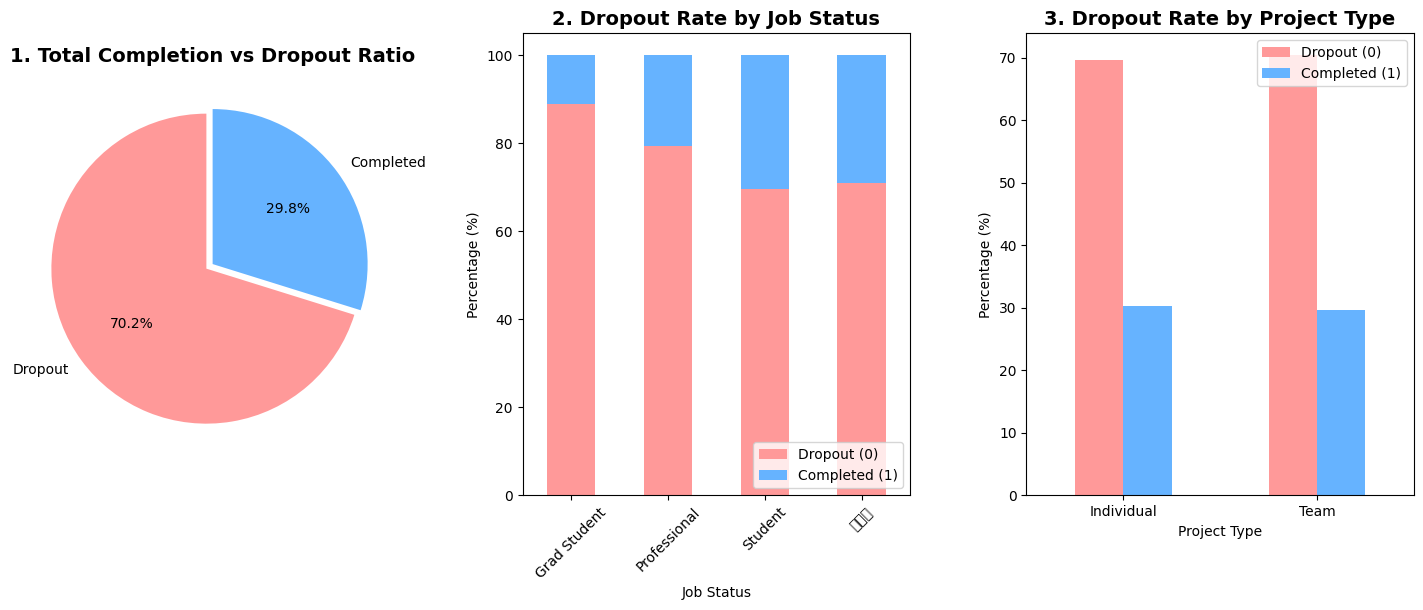

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51004 (\N{HANGUL SYLLABLE EU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local

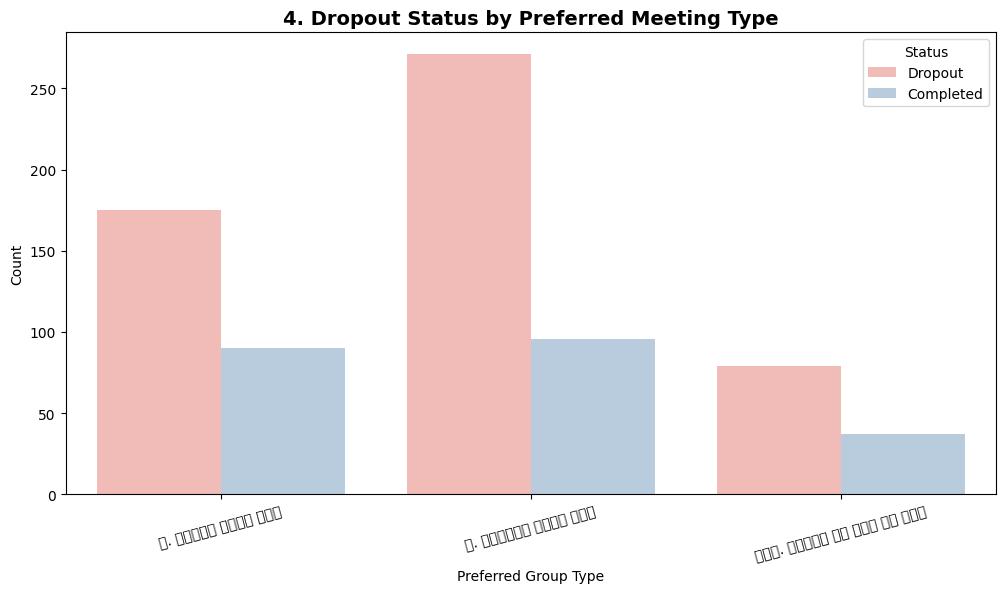

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 한글 폰트 설정 (이전 셀에서 설치한 나눔고딕 사용)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

# 1. Load Data
train = pd.read_csv('train.csv')

# Preprocessing: Map Korean values to English for clean plotting
train['is_dropout'] = train['completed'].apply(lambda x: 'Dropout' if x == 0 else 'Completed')

# Mapping Job categories (Adjust based on your actual data values)
job_map = {
    '대학생': 'Student',
    '직장인': 'Professional',
    '취업준비생': 'Job Seeker',
    '대학원생': 'Grad Student',
    '기타': 'Etc'
}
train['job_eng'] = train['job'].map(job_map).fillna(train['job'])

# Mapping Project Type
type_map = {'팀': 'Team', '개인': 'Individual'}
train['project_type_eng'] = train['project_type'].map(type_map).fillna(train['project_type'])

# Plotting Setup
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.subplots_adjust(wspace=0.3)

# [질문 1] 활동 중 전체 이탈률은 어느 수준인가?

dropout_counts = train['is_dropout'].value_counts()
axes[0].pie(dropout_counts, labels=dropout_counts.index, autopct='%.1f%%',
            startangle=90, colors=['#ff9999','#66b3ff'], explode=[0.05, 0])
axes[0].set_title('1. Total Completion vs Dropout Ratio', fontsize=14, fontweight='bold')

# [질문 2] 신분(직장/학생)에 따른 이탈률 차이
job_dropout = train.groupby('job_eng')['completed'].value_counts(normalize=True).unstack() * 100
# Ensure columns are 0 and 1 for consistent coloring
job_dropout.plot(kind='bar', stacked=True, ax=axes[1], color=['#ff9999','#66b3ff'])
axes[1].set_title('2. Dropout Rate by Job Status', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Job Status')
axes[1].legend(['Dropout (0)', 'Completed (1)'], loc='lower right')
axes[1].tick_params(axis='x', rotation=45)

# [질문 3] 활동 방식(프로젝트 타입)에 따른 이탈률
type_dropout = train.groupby('project_type_eng')['completed'].value_counts(normalize=True).unstack() * 100
type_dropout.plot(kind='bar', ax=axes[2], color=['#ff9999','#66b3ff'])
axes[2].set_title('3. Dropout Rate by Project Type', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Percentage (%)')
axes[2].set_xlabel('Project Type')
axes[2].legend(['Dropout (0)', 'Completed (1)'])
axes[2].tick_params(axis='x', rotation=0)

plt.show()

# [추가 분석] 희망 활동 방식(Online vs Offline)에 따른 이탈률
plt.figure(figsize=(12, 6))
sns.countplot(data=train, x='hope_for_group', hue='is_dropout', palette='Pastel1')
plt.title('4. Dropout Status by Preferred Meeting Type', fontsize=14, fontweight='bold')
plt.xlabel('Preferred Group Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.legend(title='Status')
plt.show()

# **Feature Selection**

In [55]:
# 기존의 features 리스트에 새로 만든 변수와 텍스트 변수를 추가합니다.
features = [
    'generation', 'school1', 'major type', 'major_data', 'job',
    're_registration', 'nationality', 'inflow_route', 'major_field',
    'desired_career_path', 'completed_semester', 'project_type',
    'time_input', 'desired_job', 'certificate_acquisition',
    'incumbents_level', 'incumbents_lecture', 'incumbents_company_level',
    'incumbents_lecture_type', 'incumbents_lecture_scale',
    # --- 핵심: 아래 텍스트와 파생 변수를 꼭 넣어야 점수가 오릅니다 ---
    'whyBDA', 'what_to_gain', 'incumbents_lecture_scale_reason',
    'why_len', 'gain_len', 'cert_count', 'domain_count'
]
target = 'completed'

X = train[features]
y = train[target]
X_test = test[features]

# CatBoost에 알려줄 피처 종류 정의 (매우 중요)
cat_cols = ['major type', 'job', 'inflow_route', 'desired_job', 'project_type', 'certificate_acquisition', 'incumbents_level']
text_cols = ['whyBDA', 'what_to_gain'] # 텍스트 피처 지정
num_cols = [c for c in features if c not in cat_cols and c not in text_cols]

In [56]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [57]:
# 1. 리스트형태 데이터 개수 세기 (Feature Engineering)
def count_items(x):
    if pd.isna(x) or x == '없음':
        return 0
    return len(str(x).split(','))

# 자격증 개수, 관심 도메인 개수 등을 수치화
list_cols = ['desired_certificate', 'certificate_acquisition', 'expected_domain', 'onedayclass_topic']
for col in list_cols:
    train[f'{col}_count'] = train[col].apply(count_items)
    test[f'{col}_count'] = test[col].apply(count_items)

# 2. 결측치 채우기 (CatBoost가 인식하기 쉽게 문자열로 변환)
# 수치형은 그대로 두고, 객체(Object) 타입만 채움
obj_cols = train.select_dtypes(include=['object']).columns.tolist()
if 'completed' in obj_cols: obj_cols.remove('completed')

train[obj_cols] = train[obj_cols].fillna('None')
test[obj_cols] = test[obj_cols].fillna('None')

# 3. 피처 분류 (중요!)
# 범주형 피처 리스트
cat_features = [
    'major type', 'major1_1', 'major1_2', 'job', 're_registration',
    'nationality', 'inflow_route', 'hope_for_group', 'major_field',
    'desired_career_path', 'project_type', 'desired_job',
    'incumbents_level', 'incumbents_lecture', 'incumbents_company_level',
    'incumbents_lecture_type', 'incumbents_lecture_scale'
]

# 텍스트 피처 리스트 (문장으로 된 데이터)
text_features = ['whyBDA', 'what_to_gain', 'incumbents_lecture_scale_reason']

# 나머지 수치형 피처
features = [col for col in train.columns if col != 'completed']

# **Modeling**

In [87]:
from catboost import Pool, CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

# Redefine selected features and target based on previous steps
selected_features = [
    'generation', 'school1', 'class1', 'class2', 'class3', 'class4',
    'completed_semester', 'time_input', 'contest_award', 'major type',
    'major_data', 'job', 'inflow_route', 'desired_job', 'project_type',
    'certificate_acquisition', 'incumbents_level',
    'whyBDA', 'what_to_gain' # Add text features to selected_features
]
target_col = 'completed'

# Define columns to force as categorical, as per cell Y0JrjNejXIlp
force_cat_cols = [
    'generation', 'school1', 'class1', 'class2', 'class3', 'class4',
    'completed_semester'
]


X_working = train[selected_features].copy()
y_working = train[target_col].copy()
test_working = test[selected_features].copy()

all_current_cols = X_working.columns.tolist()

# Identify categorical columns: object dtypes + forced categorical columns
cat_cols_for_catboost_model = list(set(X_working.select_dtypes(include='object').columns.tolist() + [col for col in force_cat_cols if col in all_current_cols]))

# Identify numerical columns: all other columns not in cat_cols_for_catboost_model
num_cols_for_catboost_model = [col for col in all_current_cols if col not in cat_cols_for_catboost_model]

# Apply preprocessing to X_working and test_working
for col in cat_cols_for_catboost_model:
    # Fill NaNs with 'missing' and convert to string type for categorical features
    X_working[col] = X_working[col].fillna('missing').astype(str)
    test_working[col] = test_working[col].fillna('missing').astype(str)

for col in num_cols_for_catboost_model:
    # Use median from X_working for imputation to avoid data leakage
    med = X_working[col].median()
    X_working[col] = X_working[col].fillna(med)
    test_working[col] = test_working[col].fillna(med)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_working))
test_preds = np.zeros(len(test_working))

# Define CatBoost specific text features. Now 'whyBDA' and 'what_to_gain' are in selected_features.
catboost_text_features = ['whyBDA', 'what_to_gain']

for fold, (train_idx, val_idx) in enumerate(skf.split(X_working, y_working)):
    X_train_fold, X_val_fold = X_working.iloc[train_idx], X_working.iloc[val_idx]
    y_train_fold, y_val_fold = y_working.iloc[train_idx], y_working.iloc[val_idx]

    # CatBoost 전용 데이터 객체 Pool 생성
    train_pool = Pool(X_train_fold, y_train_fold, cat_features=cat_cols_for_catboost_model, text_features=catboost_text_features)
    val_pool = Pool(X_val_fold, y_val_fold, cat_features=cat_cols_for_catboost_model, text_features=catboost_text_features)

    cat_model = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.01,
        depth=7,
        eval_metric='F1',
        auto_class_weights='Balanced', # 불균형 해결
        early_stopping_rounds=200,
        random_state=42,
        verbose=200
    )

    cat_model.fit(
        train_pool, # Fit using the Pool object for the current fold
        eval_set=val_pool, # Evaluate using the Pool object for the current fold
        use_best_model=True
    )

    # 검증 및 테스트 데이터 예측
    oof_preds[val_idx] = cat_model.predict(X_val_fold)
    test_preds += cat_model.predict_proba(test_working[selected_features])[:, 1] / 5

print(f"Overall F1 Score: {f1_score(y_working, oof_preds):.4f}")

0:	learn: 0.6336026	test: 0.6811961	best: 0.6811961 (0)	total: 39.3ms	remaining: 1m 57s
200:	learn: 0.8805031	test: 0.5336722	best: 0.6811961 (0)	total: 4.62s	remaining: 1m 4s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.6811961435
bestIteration = 0

Shrink model to first 1 iterations.
0:	learn: 0.6793150	test: 0.4645477	best: 0.4645477 (0)	total: 22ms	remaining: 1m 5s
200:	learn: 0.9181062	test: 0.4031742	best: 0.5061301 (2)	total: 4.81s	remaining: 1m 7s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.5061301431
bestIteration = 2

Shrink model to first 3 iterations.
0:	learn: 0.6453188	test: 0.3468869	best: 0.3468869 (0)	total: 22.1ms	remaining: 1m 6s
200:	learn: 0.8783608	test: 0.5064207	best: 0.5497069 (74)	total: 5.74s	remaining: 1m 19s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.549706933
bestIteration = 74

Shrink model to first 75 iterations.
0:	learn: 0.6470642	test: 0.4153276	best: 0.4153276 (0)	total: 22.1m

In [88]:
# K-Fold 내부에서 찾은 베스트 임계값들의 평균을 사용하거나,
# 전체 OOF(Out-of-Fold) 예측값으로 단 하나의 최적 임계값을 찾으세요.

from sklearn.metrics import f1_score

def find_best_threshold(y_true, y_probs):
    best_thresh = 0.5
    best_f1 = 0
    for thresh in np.arange(0.1, 0.7, 0.01):
        score = f1_score(y_true, (y_probs > thresh).astype(int))
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
    return best_thresh

# 적용 예시
target_threshold = find_best_threshold(y, oof_preds)
final_preds = (test_preds > target_threshold).astype(int)

# **Inference**

In [91]:
# 전체 검증 점수 확인
print(f"Overall F1 Score: {f1_score(y_working, oof_preds):.4f}")

Overall F1 Score: 0.4704


In [95]:
# 1. 검증 데이터의 확률값을 가져옵니다. (oof_preds는 이미 확률 값을 포함)
val_probs = oof_preds

# 2. 0.01 단위로 threshold를 바꿔가며 최적의 점수 찾기
best_thresh = 0.1
best_f1 = 0

for thresh in np.arange(0.1, 0.9, 0.01):
    score = f1_score(y_working, (val_probs > thresh).astype(int))
    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

print(f"최적 임계값: {best_thresh}, 그때의 F1: {best_f1}")

# 3. 최종 제출 파일 생성 시 이 임계값을 적용하세요!
final_preds = (test_preds > best_thresh).astype(int)


# 결과 확인
print(f"최종 예측된 수료자 수: {final_preds.sum()}명")


최적 임계값: 0.1, 그때의 F1: 0.47038327526132406
최종 예측된 수료자 수: 814명


# **Submission**

In [73]:
# 제출 파일 저장
submission['completed'] = final_preds
submission.to_csv('submission_catboost7.csv', index=False)
print("제출 파일이 성공적으로 생성되었습니다!")

제출 파일이 성공적으로 생성되었습니다!


# 전체 코드 및 총 정리
모델의 F1 점수를 개선하기 위해 CatBoost 모델링을 담당하는 기존의 셀을 수정하여 더 많은 피처를 활용하고 하이퍼파라미터를 튜닝하며, 피처 타입 자동 분류 및 결측치 처리를 통합하였습니다. 또한, 불필요한 F1 점수 출력 셀과 중복된 최적 임계값 탐색 셀을 삭제했습니다. 수정된 모델로 학습을 수행하고 새로운 F1 점수를 확인한 후, 테스트 데이터에 대한 예측을 생성하여 최종 제출 파일을 만들려고 합니다.

## **CatBoost Modeling 수정**

### Subtask:

CatBoost 모델 학습을 담당하는 셀을 수정하고, 이를 통해 더 많은 피처를 활용하고, CatBoost 하이퍼파라미터(학습률, 깊이, 반복 횟수, L2 정규화 등)를 튜닝하여 F1 점수 개선을 목표로 합니다. 또한, 피처 타입을 자동으로 분류하고 결측치 처리를 통합하였습니다.


In [96]:
# 필요한 라이브러리 임포트
from catboost import Pool, CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

# 'completed' 컬럼을 제외한 모든 컬럼을 선택 피처로 정의
target_col = 'completed'
# train 데이터프레임의 모든 컬럼을 selected_features로 사용하되, 타겟 컬럼은 제외
selected_features = [col for col in train.columns if col != target_col]

# 데이터 복사본 생성
X_working = train[selected_features].copy()
y_working = train[target_col].copy()
test_working = test[selected_features].copy()

# CatBoost 모델의 피처 타입 자동 분류 및 결측치 처리 통합

# 텍스트 피처 정의 (CatBoost가 텍스트로 처리할 컬럼들)
catboost_text_features = ['whyBDA', 'what_to_gain', 'incumbents_lecture_scale_reason']

# 범주형 피처 정의: object 타입 중 텍스트 피처에 포함되지 않는 컬럼들
cat_cols_for_catboost_model = [
    col for col in X_working.select_dtypes(include='object').columns.tolist()
    if col not in catboost_text_features
]

# 숫자형 및 불리언 피처 정의: int64, float64, bool 타입 컬럼들
num_cols_for_catboost_model = X_working.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()

# 결측치 처리: CatBoost 모델 학습 전에 모든 데이터에 적용
for col in cat_cols_for_catboost_model:
    # 범주형 피처의 결측치는 'None' 문자열로 채우고, 타입은 문자열로 변환 (CatBoost가 범주형으로 인식하도록)
    X_working[col] = X_working[col].fillna('None').astype(str)
    test_working[col] = test_working[col].fillna('None').astype(str)

for col in catboost_text_features:
    # 텍스트 피처의 결측치는 'None' 문자열로 채우고, 타입은 문자열로 변환
    X_working[col] = X_working[col].fillna('None').astype(str)
    test_working[col] = test_working[col].fillna('None').astype(str)

for col in num_cols_for_catboost_model:
    # 숫자형/불리언 피처의 결측치는 훈련 데이터의 중앙값으로 채움 (데이터 누수 방지)
    med = X_working[col].median()
    X_working[col] = X_working[col].fillna(med)
    test_working[col] = test_working[col].fillna(med)

# Stratified K-Fold 설정 및 OOF(Out-of-Fold) 예측 배열 초기화
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_working))
test_preds = np.zeros(len(test_working))

# K-Fold 교차 검증 루프 시작
for fold, (train_idx, val_idx) in enumerate(skf.split(X_working, y_working)):
    # 각 폴드별 훈련 및 검증 데이터 분할
    X_train_fold, X_val_fold = X_working.iloc[train_idx], X_working.iloc[val_idx]
    y_train_fold, y_val_fold = y_working.iloc[train_idx], y_working.iloc[val_idx]

    # CatBoost 전용 데이터 객체 Pool 생성
    # cat_features와 text_features를 CatBoost에 명시하여 자동으로 처리하도록 함
    train_pool = Pool(
        X_train_fold,
        y_train_fold,
        cat_features=cat_cols_for_catboost_model,
        text_features=catboost_text_features
    )
    val_pool = Pool(
        X_val_fold,
        y_val_fold,
        cat_features=cat_cols_for_catboost_model,
        text_features=catboost_text_features
    )

    # CatBoostClassifier 모델 하이퍼파라미터 튜닝
    cat_model = CatBoostClassifier(
        iterations=5000,              # 최대 학습 반복 횟수 증가
        learning_rate=0.005,          # 학습률 감소
        depth=8,                      # 모델 깊이 증가
        l2_leaf_reg=5,                # L2 정규화 강도 증가
        colsample_bylevel=0.8,        # 각 트리 분할 시 사용될 피처 샘플링 비율 설정
        eval_metric='F1',             # 평가 지표 F1 스코어로 설정
        auto_class_weights='Balanced', # 클래스 불균형 자동 처리
        early_stopping_rounds=500,    # 조기 종료 라운드 증가 (과적합 방지)
        random_state=42,              # 재현성을 위한 랜덤 시드 고정
        verbose=200                   # 200번 반복마다 학습 로그 출력
    )

    # CatBoost 모델 학습
    cat_model.fit(
        train_pool,                   # Pool 객체를 사용하여 학습 데이터 지정
        eval_set=val_pool,            # Pool 객체를 사용하여 검증 데이터 지정
        use_best_model=True           # 검증 세트에서 최적의 성능을 보인 모델을 저장
    )

    # 검증 데이터 예측 (OOF 예측)
    oof_preds[val_idx] = cat_model.predict(X_val_fold)
    # 테스트 데이터 예측 (클래스 1에 대한 확률을 각 폴드별로 누적 후 평균)
    test_preds += cat_model.predict_proba(test_working[selected_features])[:, 1] / skf.n_splits

# 전체 OOF F1 스코어 출력
print(f"Overall F1 Score: {f1_score(y_working, oof_preds):.4f}")

0:	learn: 0.6500542	test: 0.6355174	best: 0.6355174 (0)	total: 170ms	remaining: 14m 9s
200:	learn: 0.8879856	test: 0.4795487	best: 0.6355174 (0)	total: 34.7s	remaining: 13m 49s
400:	learn: 0.9494545	test: 0.4175840	best: 0.6355174 (0)	total: 1m 5s	remaining: 12m 30s
Stopped by overfitting detector  (500 iterations wait)

bestTest = 0.6355174412
bestIteration = 0

Shrink model to first 1 iterations.
0:	learn: 0.4840879	test: 0.4174397	best: 0.4174397 (0)	total: 134ms	remaining: 11m 8s
200:	learn: 0.8668498	test: 0.4728251	best: 0.5433057 (38)	total: 31.9s	remaining: 12m 42s
400:	learn: 0.9332705	test: 0.4576630	best: 0.5433057 (38)	total: 1m 8s	remaining: 13m 3s
Stopped by overfitting detector  (500 iterations wait)

bestTest = 0.5433056942
bestIteration = 38

Shrink model to first 39 iterations.
0:	learn: 0.6631609	test: 0.4781965	best: 0.4781965 (0)	total: 191ms	remaining: 15m 54s
200:	learn: 0.8337266	test: 0.4769019	best: 0.5089147 (7)	total: 42.9s	remaining: 17m 3s
400:	learn: 0.89

In [97]:
from sklearn.metrics import f1_score

# OOF 예측 (확률 값)과 실제 타겟 값을 사용하여 최적의 임계값 탐색
def find_best_threshold(y_true, y_probs):
    best_thresh = 0.5  # 초기 임계값 설정
    best_f1 = 0  # 초기 최고 F1 점수 설정
    # 0.1부터 0.9까지 0.01 간격으로 임계값을 변경하며 최적 값 탐색
    for thresh in np.arange(0.1, 0.9, 0.01):
        score = f1_score(y_true, (y_probs > thresh).astype(int)) # 현재 임계값으로 이진 분류 후 F1 스코어 계산
        if score > best_f1: # 현재 F1 스코어가 최고 F1 스코어보다 높으면 업데이트
            best_f1 = score
            best_thresh = thresh
    return best_thresh, best_f1 # 최적 임계값과 그때의 F1 스코어 반환

# 훈련 데이터의 OOF 예측과 실제 타겟 값을 사용하여 최적 임계값 찾기
target_threshold, best_oof_f1 = find_best_threshold(y_working, oof_preds)

print(f"OOF 예측에 대한 최적 임계값: {target_threshold:.2f}")
print(f"이때의 OOF F1 Score: {best_oof_f1:.4f}")

# 테스트 데이터 예측에 최적 임계값 적용
final_preds = (test_preds > target_threshold).astype(int)

# 최종 예측된 수료자 수 확인
print(f"최종 예측된 수료자 수: {final_preds.sum()}명")


OOF 예측에 대한 최적 임계값: 0.10
이때의 OOF F1 Score: 0.4604
최종 예측된 수료자 수: 814명


In [99]:
submission['completed'] = final_preds
submission.to_csv('submission_catboost8.csv', index=False)
print("제출 파일이 성공적으로 생성되었습니다!")

제출 파일이 성공적으로 생성되었습니다!
